# Project 5 - Stock Market and Portfolio Risk Analysis

**Domain:** Finance  
**Data:** Simulated fictional assets  
**Purpose:** Educational portfolio analysis; not investment advice.

## 1. Setup and loading

In [1]:
from pathlib import Path
import sys,pandas as pd,numpy as np
ROOT=Path.cwd() if (Path.cwd()/'src').exists() else Path.cwd().parent
sys.path.insert(0,str(ROOT))
from src.finance_analysis import validate_market_data,clean_market_data,asset_metrics,equal_weight_portfolio,calculate_finance_kpis
raw=pd.read_csv(ROOT/'data/project5_finance/market_prices_raw.csv')
raw.head()

,date,ticker,sector,close,volume
0,2022-01-03,AURORA,Consumer,183.22,1073110.0
1,2022-01-03,NOVA,Technology,326.81,1942852.0
2,2022-01-03,ORBIT,Financials,140.12,960875.0
3,2022-01-03,PRISM,Healthcare,252.13,452671.0
4,2022-01-03,ZENITH,Energy,210.67,1356269.0


## 2. Data validation and cleaning

In [2]:
raw_validation=validate_market_data(raw)
pd.Series(raw_validation)

rows                                             3912
columns                                             5
missing_required_columns                           []
duplicate_ticker_dates                              2
missing_values              {'close': 2, 'volume': 1}
invalid_dates                                       0
nonpositive_price_rows                              0
negative_volume_rows                                0
dtype: object

In [3]:
market=clean_market_data(raw)
print(f'{len(raw):,} raw rows -> {len(market):,} cleaned observations')
validate_market_data(market)

3,912 raw rows -> 3,910 cleaned observations


{'rows': 3910,
 'columns': 10,
 'missing_required_columns': [],
 'duplicate_ticker_dates': 0,
 'missing_values': {},
 'invalid_dates': 0,
 'nonpositive_price_rows': 0,
 'negative_volume_rows': 0}

## 3. Descriptive statistics and KPIs

In [4]:
kpis=calculate_finance_kpis(market)
pd.Series(kpis).to_frame('Value')

,Value
observations,3910
assets,5
start_date,2022-01-03
end_date,2024-12-31
best_asset,ORBIT
best_asset_annualized_return_pct,31.42
lowest_volatility_asset,PRISM
lowest_volatility_pct,17.39
portfolio_total_return_pct,52.15
portfolio_annualized_return_pct,15.07


In [5]:
market.groupby('ticker')[['close','volume','daily_return','rolling_volatility_21d','drawdown']].describe().round(4)

close                                                                  \
        count      mean      std     min       25%      50%       75%     max   
ticker                                                                          
AURORA  782.0  206.6297  25.0435  157.95  187.8950  205.310  224.6125  268.93   
NOVA    782.0  376.1667  49.2164  287.76  338.2375  368.770  407.7675  523.78   
ORBIT   782.0  219.9029  56.1489  124.83  170.2200  219.275  253.8275  342.91   
PRISM   782.0  326.1666  51.2934  244.64  290.8925  314.890  345.6875  456.05   
ZENITH  782.0  216.6446  23.7695  173.61  199.9600  210.855  224.5000  290.40   

       volume                ... rolling_volatility_21d         drawdown  \
        count          mean  ...                    75%     max    count   
ticker                       ...                                           
AURORA  782.0  9.621658e+05  ...                 0.2021  0.2473    782.0   
NOVA    782.0  1.467548e+06  ...                 0.3294  0.4217    782.0   
ORBIT   782.0  1.155364e+06  ...                 0.2423  0.3301    782.0   
PRISM   782.0  7.388944e+05  ...                 0.1862  0.2367    782.0   
ZENITH  782.0  1.341492e+06  ...                 0.2802  0.3541    782.0   

                                                             
          mean     std     min     25%     50%     75%  max  
ticker                                                       
AURORA -0.1617  0.1336 -0.4127 -0.2954 -0.1413 -0.0339  0.0  
NOVA   -0.1529  0.1000 -0.4071 -0.2213 -0.1539 -0.0665  0.0  
ORBIT  -0.0567  0.0520 -0.2020 -0.0995 -0.0410 -0.0105  0.0  
PRISM  -0.0627  0.0500 -0.1973 -0.0921 -0.0583 -0.0166  0.0  
ZENITH -0.1752  0.1159 -0.3773 -0.2860 -0.2030 -0.0649  0.0  

[5 rows x 40 columns]

## 4. Asset metrics

In [6]:
metrics=asset_metrics(market,risk_free_rate=.06)
metrics.round(3)

,ticker,sector,start_price,end_price,total_return_pct,annualized_return_pct,annualized_volatility_pct,sharpe_ratio,max_drawdown_pct,average_daily_volume
0,ORBIT,Financials,140.12,317.42,126.534,31.424,22.504,1.019,-20.201,1155364.292
1,PRISM,Healthcare,252.13,414.07,64.229,18.031,17.389,0.663,-19.728,738894.379
2,NOVA,Technology,326.81,439.56,34.500,10.412,30.343,0.269,-40.714,1467547.849
3,AURORA,Consumer,183.22,219.08,19.572,6.155,18.594,0.080,-41.267,962165.783
4,ZENITH,Energy,210.67,227.39,7.937,2.585,25.575,-0.010,-37.734,1341492.038


## 5. Equal-weight portfolio

In [7]:
portfolio,portfolio_metrics=equal_weight_portfolio(market,risk_free_rate=.06)
pd.Series(portfolio_metrics).to_frame('Value')

,Value
portfolio_total_return_pct,52.150
portfolio_annualized_return_pct,15.070
portfolio_annualized_volatility_pct,15.640
portfolio_sharpe_ratio,0.561
portfolio_max_drawdown_pct,-18.010


## 6. Correlation and diversification

In [8]:
returns=market.pivot(index='date',columns='ticker',values='daily_return')
returns.corr().round(3)

ticker,AURORA,NOVA,ORBIT,PRISM,ZENITH
ticker,,,,,
AURORA,1.000,0.417,0.289,0.230,0.308
NOVA,0.417,1.000,0.474,0.309,0.254
ORBIT,0.289,0.474,1.000,0.420,0.299
PRISM,0.230,0.309,0.420,1.000,0.216
ZENITH,0.308,0.254,0.299,0.216,1.000


## 7. Trend statistics

In [9]:
market.assign(year=market.date.dt.year).groupby(['year','ticker']).daily_return.apply(lambda r:((1+r.dropna()).prod()-1)*100).unstack().round(2)

ticker,AURORA,NOVA,ORBIT,PRISM,ZENITH
year,,,,,
2022,26.65,-0.46,32.22,14.59,14.84
2023,-19.66,31.76,39.49,14.08,-16.97
2024,17.52,2.55,22.83,25.63,13.20


## 8. Visualizations

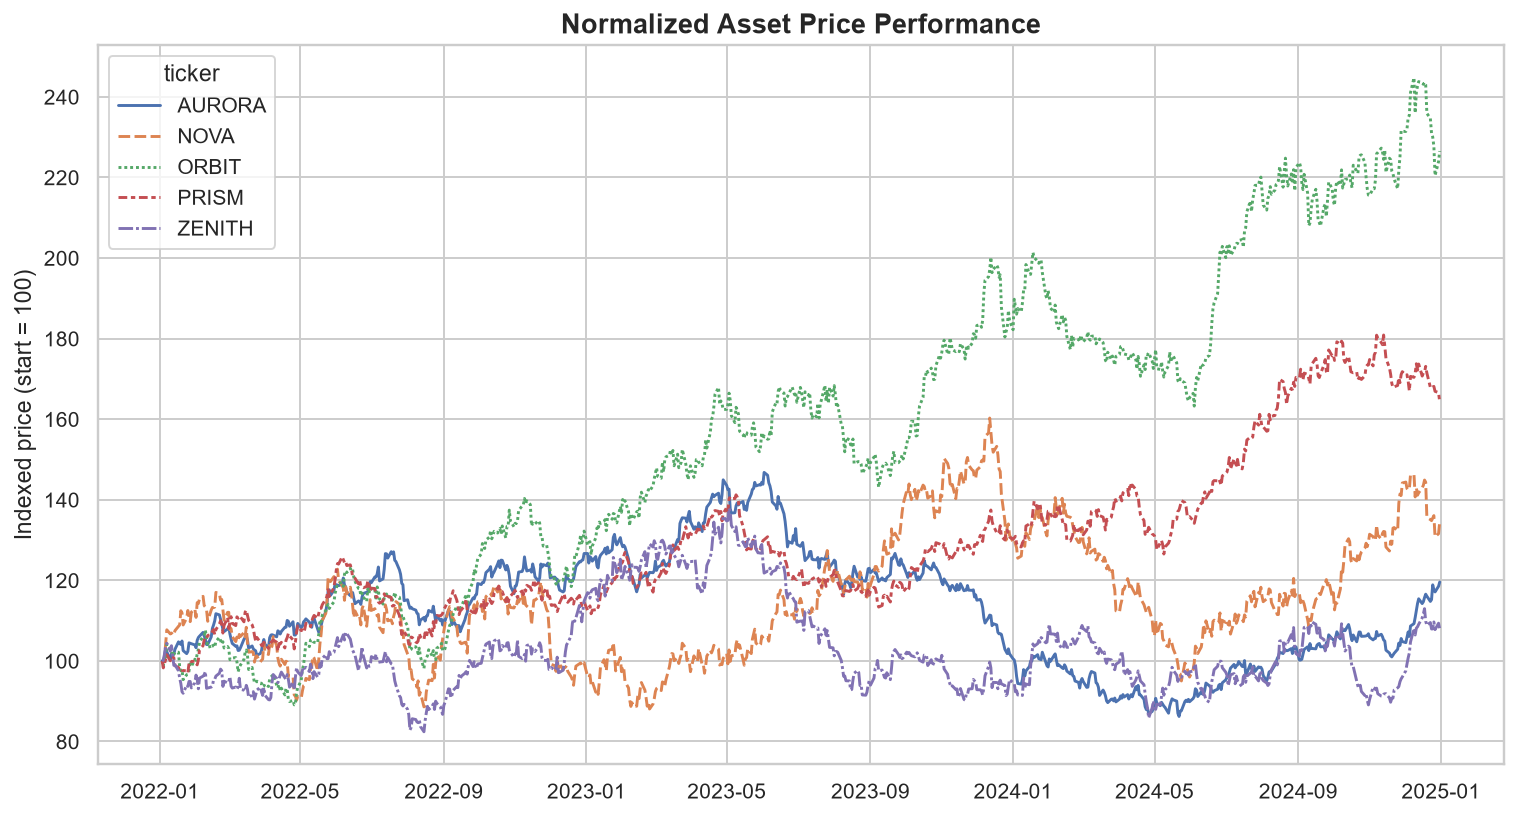

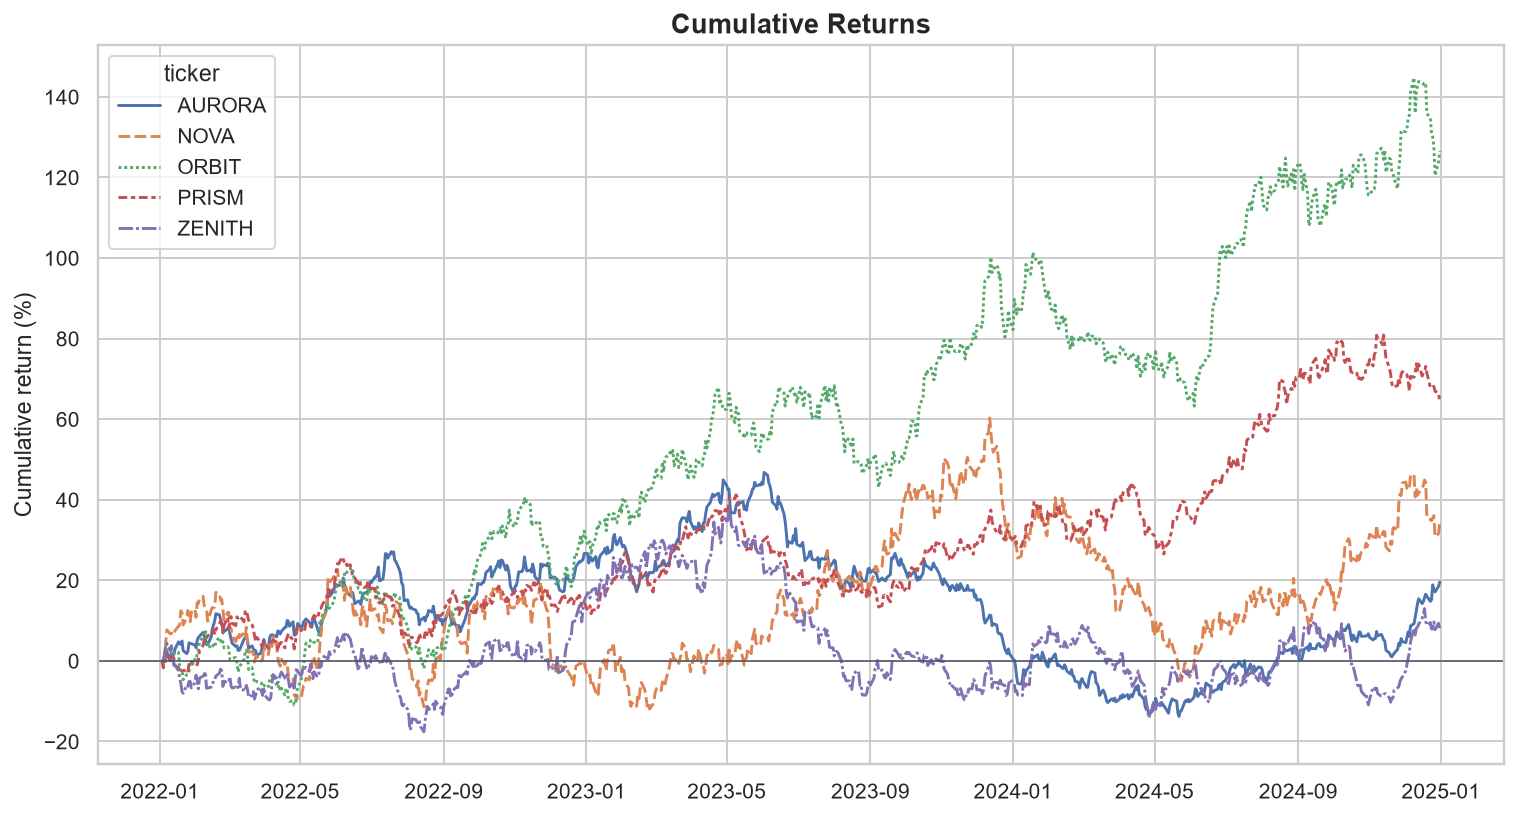

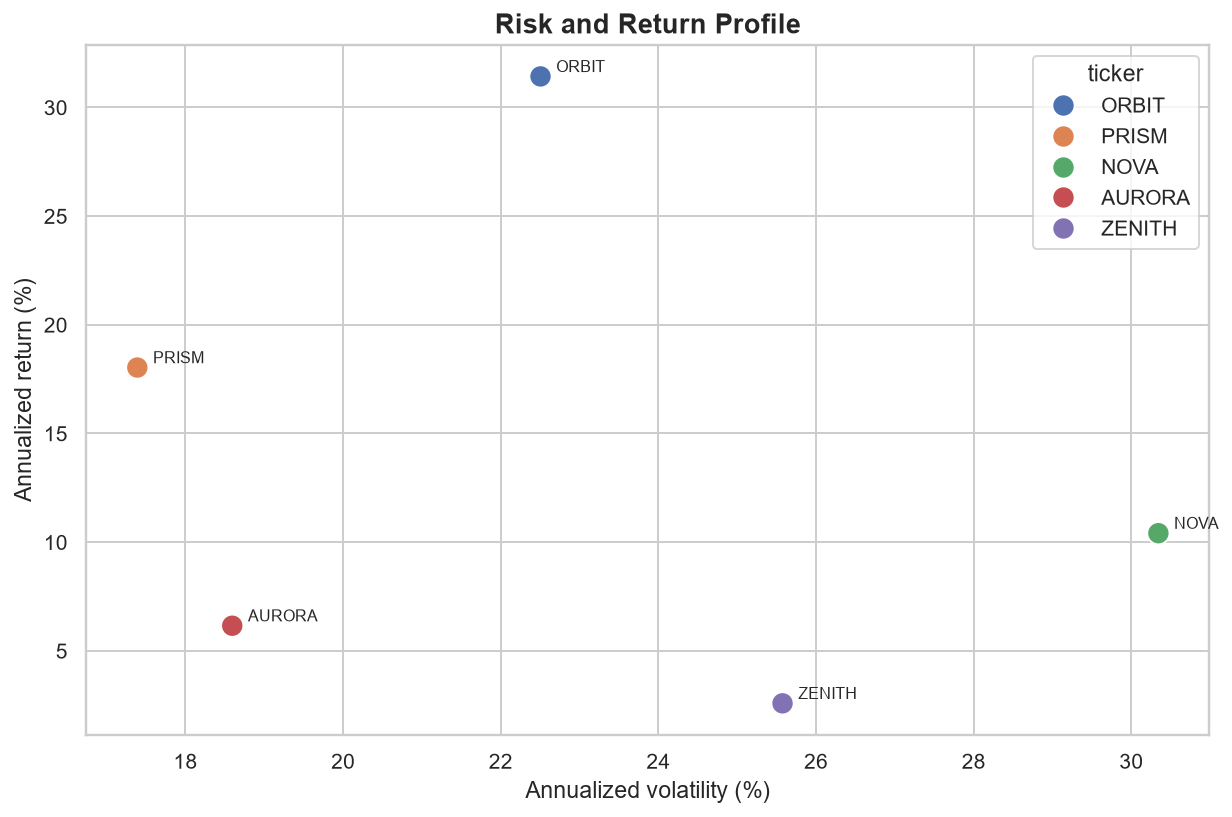

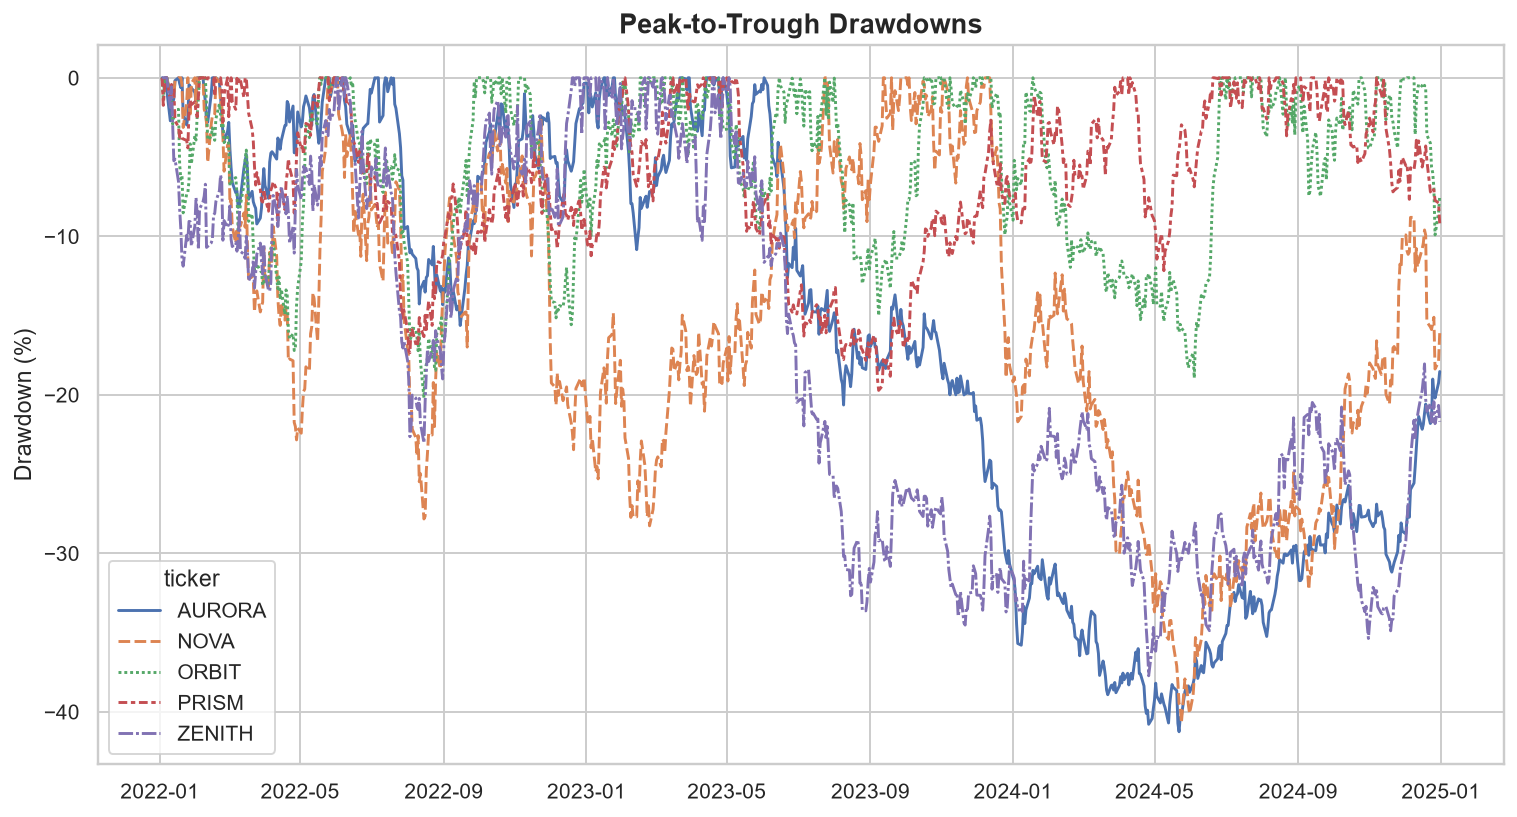

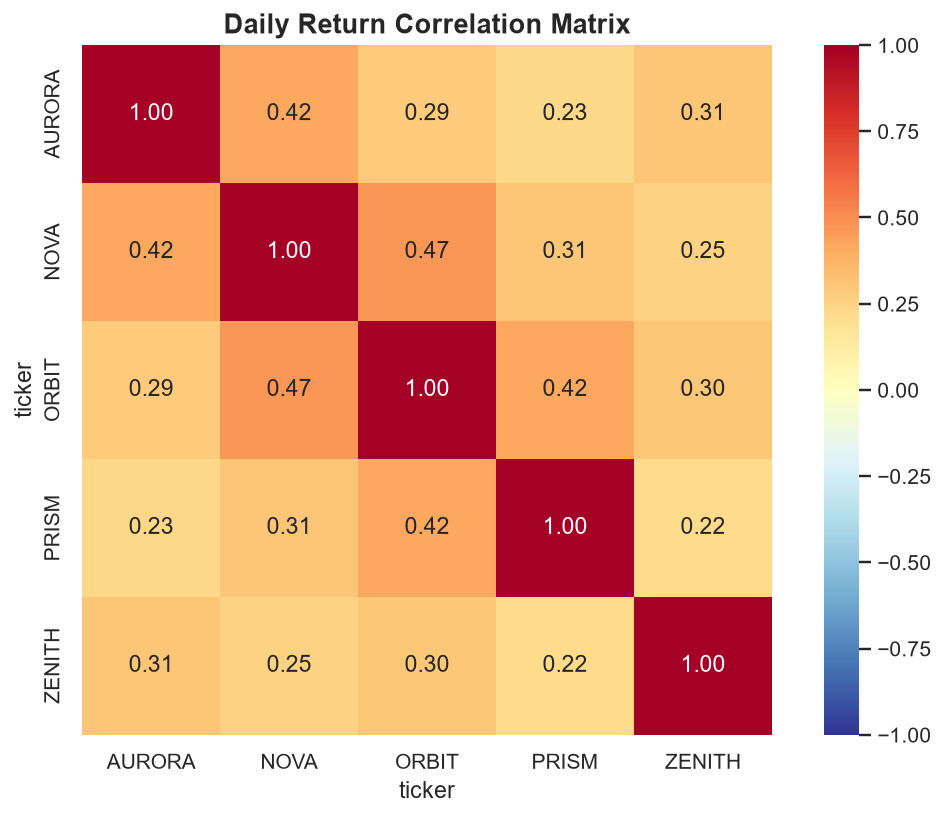

In [10]:
from IPython.display import display,Image
for chart in sorted((ROOT/'visualizations/project5_finance').glob('*.png')): display(Image(filename=str(chart),width=850))

## 9. Portfolio insights
1. Evaluate return with volatility and drawdown.
2. Use correlation for diversification, recognising it is unstable.
3. Compare all assets over the same period.
4. Add fees, taxes, dividends, and realistic rebalancing before practical use.
5. Treat results as educational, not investment advice.

## 10. Assumptions and limitations
252 trading days, 6% annual risk-free rate, equal weights, daily rebalancing, no fees/taxes/slippage/dividends. Simulated past performance does not predict future results.